# Notebook 5: Baseline Strategy

 Starting Strategy Backtest...


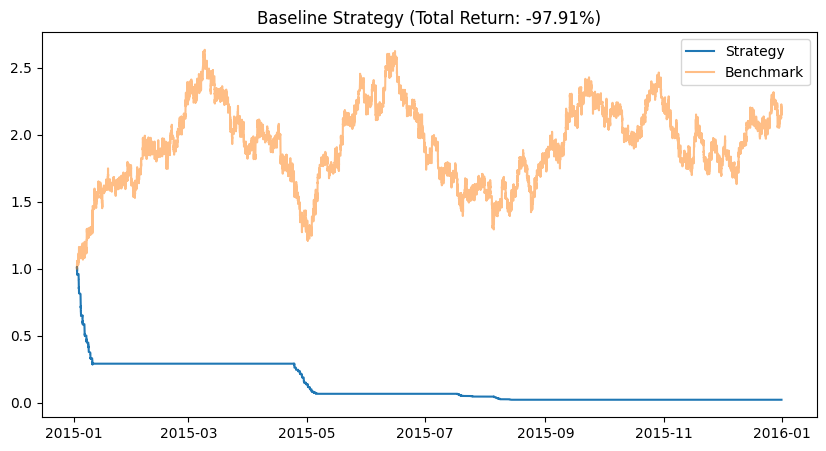

Baseline Strategy Backtested.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(" Starting Strategy Backtest...")
df = pd.read_csv("../data/nifty_regimes.csv", index_col='timestamp', parse_dates=True)

# 1. Strategy Logic (Task 4.1)
df['signal'] = 0
# Long: EMA 5 > 15 AND Bull Regime
df.loc[(df['ema_5'] > df['ema_15']) & (df['regime'] == 1), 'signal'] = 1
# Short: EMA 5 < 15 AND Bear Regime
df.loc[(df['ema_5'] < df['ema_15']) & (df['regime'] == -1), 'signal'] = -1

# 2. Backtest Calculation (Task 4.2)
df['strategy_pnl'] = df['signal'].shift(1) * df['returns']
df['cumulative_return'] = (1 + df['strategy_pnl']).cumprod()
df['benchmark_return'] = (1 + df['returns']).cumprod()

# 3. Metrics & Visualization
total_return = df['cumulative_return'].iloc[-1] - 1
sharpe = df['strategy_pnl'].mean() / df['strategy_pnl'].std() * np.sqrt(252*75) # Annualized

plt.figure(figsize=(10, 5))
plt.plot(df['cumulative_return'], label='Strategy')
plt.plot(df['benchmark_return'], label='Benchmark', alpha=0.5)
plt.title(f"Baseline Strategy (Total Return: {total_return*100:.2f}%)")
plt.legend()
plt.savefig("../results/output-2.png")
plt.show()

# 4. Save
df.to_csv("../data/nifty_backtest.csv")
print("Baseline Strategy Backtested.")